# 학습 파이프라인 구축

Pytorch를 사용하여 학습 파이프라인을 구축하는 과제 노트북입니다.

진행 순서는 다음과 같습니다.

1. 데이터 다운로드 후 전처리
2. Pytorch Dataset 생성
3. Pytorch DataLoader 생성
4. 모델 구축
5. 모델 학습

## 1. 데이터를 다운로드 후 전처리
    - 예측 값 y는 성별(sex)와 생존여부(survived)이며 입력 데이터 X에 포함되어선 안 됩니다.
    - 입력할 데이터 X에 포함될 수치형 데이터는 평균이 0, 분산이 1인 표준편차가 되어야합니다.
    - 입력할 데이터 X에 범주형 데이터를 사용할 경우 class로 변환되어야합니다.
    - Train 데이터와 Test 데이터를 8:2로 분할하고 만일 Validation 데이터까지 포함한다면 8:1:1 비율로 나누십시오.

### 데이터 다운로드

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [8]:
df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 정보 누설 방지 및 데이터 전처리

### 데이터 분석 및 시각화

In [22]:
import matplotlib.pyplot as plt

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [42]:
print("결측치")
display(df.isna().sum())

결측치


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
processed_df = df.copy()

# who와 adult_male을 활용해 성인 여부 feature를 만든다.
# who가 child가 아니거나 adult_male이 True이면 성인으로 처리한다.
processed_df["is_adult"] = (
    processed_df["who"].ne("child") | processed_df["adult_male"]
).astype("int64")

# embark_town과 embarked는 같은 정보를 의미하므로 embarked만 사용한다.
# embarked의 결측치는 최빈값으로 대체한 뒤 class id로 변환한다.
embarked_mode = processed_df["embarked"].mode(dropna=True).iloc[0]
processed_df["embarked"] = processed_df["embarked"].fillna(embarked_mode)
embarked_mapping = {
    value: idx for idx, value in enumerate(sorted(processed_df["embarked"].unique()))
}
processed_df["embarked_class"] = processed_df["embarked"].map(embarked_mapping).astype("int64")

# pclass와 class는 같은 선실 등급 정보이므로 pclass만 사용한다.
# sex와 survived는 예측 대상이며, sex는 학습 가능한 class id로 변환한다.
sex_mapping = {"male": 0, "female": 1}
processed_df["sex_class"] = processed_df["sex"].map(sex_mapping).astype("int64")
processed_df["survived"] = processed_df["survived"].astype("int64")

# 수치형 feature의 결측치는 중앙값으로 대체한다.
processed_df["age"] = processed_df["age"].fillna(processed_df["age"].median())
processed_df["fare"] = processed_df["fare"].fillna(processed_df["fare"].median())

# bool 타입인 alone은 모델 입력에 쓰기 쉽도록 정수 class로 변환한다.
processed_df["alone"] = processed_df["alone"].astype("int64")

feature_columns = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked_class",
    "is_adult",
    "alone",
]
target_columns = ["sex_class", "survived"]

feature_df = processed_df[feature_columns].copy()
label_df = processed_df[target_columns].copy()

print("embarked mapping:", embarked_mapping)
print("feature columns:", feature_columns)
print("target columns:", target_columns)
print("feature missing count after preprocessing:")
display(feature_df.isna().sum())
print("preprocessed feature preview:")
display(feature_df.head())
print("target preview:")
display(label_df.head())


In [60]:
processed_df.drop(['sex','embarked','class','who','adult_male','embark_town','deck','alive'], axis=1, inplace=True)
processed_df.head()

,survived,pclass,age,sibsp,parch,fare,alone,is_adult,embarked_class,sex_class
0,0,3,22.0,1,0,7.2500,0,1,2,0
1,1,1,38.0,1,0,71.2833,0,1,0,1
2,1,3,26.0,0,0,7.9250,1,1,2,1
3,1,1,35.0,1,0,53.1000,0,1,2,1
4,0,3,35.0,0,0,8.0500,1,1,2,0


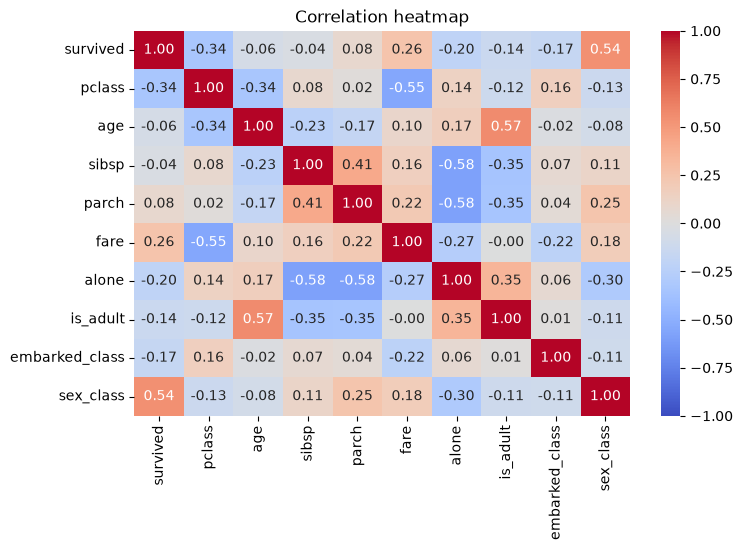

In [61]:
corr_df = processed_df.copy()
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.show()

객실 등급이 낮을수록 생존율이 낮아지는 경향  
운임이 높을수록 생존율이 높아지는 경향  
혼자 탄 승객은 생존율이 낮아지는 경향  
성인일수록 생존율이 낮아지는 경향

### 데이터 분석 결과 인사이트



### feature 선택

In [62]:
# 정제된 feature_df와 label_df를 기준으로 입력 X와 정답 y를 분리한다.
# 예측 대상인 sex_class와 survived는 X에 포함하지 않는다.
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
class_features = ["embarked_class", "is_adult", "alone"]
feature_columns = numeric_features + class_features

X_raw = feature_df[feature_columns].copy()
y_raw = label_df[["sex_class", "survived"]].copy()

print("numeric features:", numeric_features)
print("class features:", class_features)
print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)
display(X_raw.head())
display(y_raw.head())


numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
class features: ['embarked_class', 'is_adult', 'alone']
X shape: (891, 8)
y shape: (891, 2)


,pclass,age,sibsp,parch,fare,embarked_class,is_adult,alone
0,3,22.0,1,0,7.2500,2,1,0
1,1,38.0,1,0,71.2833,0,1,0
2,3,26.0,0,0,7.9250,2,1,1
3,1,35.0,1,0,53.1000,2,1,0
4,3,35.0,0,0,8.0500,2,1,1


,sex_class,survived
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


### train / vaildation / test 데이터 분리

In [63]:
# train / validation / test 데이터를 8 : 1 : 1 비율로 나눈다.
n_samples = len(X_raw)
indices = np.random.permutation(n_samples)

train_end = int(n_samples * 0.8)
valid_end = int(n_samples * 0.9)

train_idx = indices[:train_end]
valid_idx = indices[train_end:valid_end]
test_idx = indices[valid_end:]

X_train_raw = X_raw.iloc[train_idx].reset_index(drop=True)
X_valid_raw = X_raw.iloc[valid_idx].reset_index(drop=True)
X_test_raw = X_raw.iloc[test_idx].reset_index(drop=True)

y_train = y_raw.iloc[train_idx].reset_index(drop=True).to_numpy(dtype="float32")
y_valid = y_raw.iloc[valid_idx].reset_index(drop=True).to_numpy(dtype="float32")
y_test = y_raw.iloc[test_idx].reset_index(drop=True).to_numpy(dtype="float32")

# 수치형 feature는 train 데이터의 평균과 표준편차만 사용해 표준화한다.
num_mean = X_train_raw[numeric_features].mean()
num_std = X_train_raw[numeric_features].std().replace(0, 1)

def preprocess_features(frame):
    numeric = frame[numeric_features]
    numeric = ((numeric - num_mean) / num_std).astype("float32")

    classes = frame[class_features].astype("float32")
    return pd.concat([numeric.reset_index(drop=True), classes.reset_index(drop=True)], axis=1)

X_train = preprocess_features(X_train_raw)
X_valid = preprocess_features(X_valid_raw)
X_test = preprocess_features(X_test_raw)

print("train / valid / test:", X_train.shape, X_valid.shape, X_test.shape)
print("target train / valid / test:", y_train.shape, y_valid.shape, y_test.shape)
print("numeric train mean after scaling:")
display(X_train[numeric_features].mean().round(4))
print("numeric train std after scaling:")
display(X_train[numeric_features].std().round(4))


train / valid / test: (712, 8) (89, 8) (90, 8)
target train / valid / test: (712, 2) (89, 2) (90, 2)
numeric train mean after scaling:


pclass    0.0
age      -0.0
sibsp    -0.0
parch    -0.0
fare     -0.0
dtype: float32

numeric train std after scaling:


pclass    1.0
age       1.0
sibsp     1.0
parch     1.0
fare      1.0
dtype: float32

## 2. Pytorch Dataset 생성


In [64]:
class TitanicDataset(Dataset):
    def __init__(self, X, y):
        # pandas DataFrame과 numpy array를 PyTorch Tensor로 변환한다.
        self.X = torch.tensor(X.to_numpy(dtype="float32"), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # Dataset의 전체 샘플 개수를 반환한다.
        return len(self.X)

    def __getitem__(self, idx):
        # idx에 해당하는 입력 feature와 정답 label을 반환한다.
        return self.X[idx], self.y[idx]

train_dataset = TitanicDataset(X_train, y_train)
valid_dataset = TitanicDataset(X_valid, y_valid)
test_dataset = TitanicDataset(X_test, y_test)

print("input dim:", train_dataset.X.shape[1])
print("train dataset size:", len(train_dataset))
print("sample X:", train_dataset[0][0])
print("sample y [sex_class, survived]:", train_dataset[0][1])


input dim: 8
train dataset size: 712
sample X: tensor([ 0.8240,  0.9409, -0.4652,  2.0113, -0.2364,  2.0000,  1.0000,  0.0000])
sample y [sex_class, survived]: tensor([1., 0.])


## 3. Pytorch DataLoader 생성

In [65]:
batch_size = 32

# train_loader는 학습 순서가 고정되지 않도록 shuffle=True로 설정한다.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch_X, batch_y = next(iter(train_loader))
print("batch X shape:", batch_X.shape)
print("batch y shape:", batch_y.shape)


batch X shape: torch.Size([32, 8])
batch y shape: torch.Size([32, 2])


## 4. 모델 구축

In [ ]:
class TitanicMultiTaskModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # 두 개의 target(sex_class, survived)을 동시에 예측하는 다중 출력 모델이다.
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
        )

    def forward(self, x):
        # 마지막 Linear layer의 출력값은 BCEWithLogitsLoss에 넣을 logit이다.
        return self.net(x)

input_dim = train_dataset.X.shape[1]
model = TitanicMultiTaskModel(input_dim)
print(model)


TitanicMultiTaskModel(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 5. 모델 학습

### Loss function과 optimizer 설정

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [68]:
criterion = nn.BCELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 50

### 학습 루프 함수 작성

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    한 에포크 동안 모델을 학습합니다.
    Args:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        device: 계산 장치 (CPU/GPU)
    Returns:
        평균 손실값
    """
    model.train()  # 모델을 학습 모드로 설정
    total_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        outputs = model(batch_X)  # logit 형태의 출력
        
        # sigmoid 적용 (BCELoss는 확률값이 필요함)
        predictions = torch.sigmoid(outputs)
        
        # 손실 계산
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate(model, valid_loader, criterion, device):
    """
    검증 데이터에 대해 모델 성능을 평가합니다.
    
    Args:
        model: 평가할 모델
        valid_loader: 검증 데이터 로더
        criterion: 손실 함수
        device: 계산 장치
    
    Returns:
        평균 손실값, 각 task별 정확도
    """
    model.eval()  # 모델을 평가 모드로 설정
    total_loss = 0.0
    task_accuracies = np.array([0.0, 0.0])  # sex_class, survived
    
    with torch.no_grad():
        for batch_X, batch_y in valid_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            outputs = model(batch_X)
            predictions = torch.sigmoid(outputs)
            
            # 손실 계산
            loss = criterion(predictions, batch_y)
            total_loss += loss.item()
            
            # 정확도 계산 (0.5를 기준으로 분류)
            pred_classes = (predictions > 0.5).float()
            task_accuracies += (pred_classes == batch_y).float().mean(dim=0).cpu().numpy()
    
    avg_loss = total_loss / len(valid_loader)
    avg_accuracies = task_accuracies / len(valid_loader)
    
    return avg_loss, avg_accuracies

In [ ]:
import time

# 학습 발전 과정을 추적하기 위한 딕셔너리
history = {
    'train_loss': [],
    'valid_loss': [],
    'valid_sex_acc': [],
    'valid_survived_acc': []
}

print("=" * 80)
print("모델 학습 시작")
print("=" * 80)
print(f"디바이스: {device}")
print(f"총 에포크: {EPOCHS}")
print(f"배치 크기: {batch_size}")
print(f"학습 데이터: {len(train_dataset)}, 검증 데이터: {len(valid_dataset)}, 테스트 데이터: {len(test_dataset)}")
print("-" * 80)

start_time = time.time()

for epoch in range(EPOCHS):
    # 학습 에포크 실행
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_accuracies = validate(model, valid_loader, criterion, device)
    
    # 기록 저장
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['valid_sex_acc'].append(valid_accuracies[0])
    history['valid_survived_acc'].append(valid_accuracies[1])
    
    # 10 에포크마다 진행 상황 출력
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Valid Loss: {valid_loss:.4f} | "
              f"Sex Acc: {valid_accuracies[0]:.4f} | "
              f"Survived Acc: {valid_accuracies[1]:.4f}")

elapsed_time = time.time() - start_time
print("-" * 80)
print(f"학습 완료! 소요 시간: {elapsed_time:.2f}초")
print("=" * 80)

모델 학습 시작
디바이스: cpu
총 에포크: 50
배치 크기: 32
학습 데이터: 712, 검증 데이터: 89, 테스트 데이터: 90
--------------------------------------------------------------------------------
Epoch   1/50 | Train Loss: 0.5629 | Valid Loss: 0.5401 | Sex Acc: 0.7696 | Survived Acc: 0.7904
Epoch  10/50 | Train Loss: 0.5693 | Valid Loss: 0.5372 | Sex Acc: 0.7696 | Survived Acc: 0.7904
Epoch  20/50 | Train Loss: 0.5587 | Valid Loss: 0.5358 | Sex Acc: 0.7592 | Survived Acc: 0.7800
Epoch  30/50 | Train Loss: 0.5584 | Valid Loss: 0.5386 | Sex Acc: 0.7563 | Survived Acc: 0.7800
Epoch  40/50 | Train Loss: 0.5591 | Valid Loss: 0.5479 | Sex Acc: 0.7563 | Survived Acc: 0.7667
Epoch  50/50 | Train Loss: 0.5586 | Valid Loss: 0.5448 | Sex Acc: 0.7563 | Survived Acc: 0.7904
--------------------------------------------------------------------------------
학습 완료! 소요 시간: 1.24초


### 모델 학습 실행


📊 최종 성능 평가

[테스트 세트 결과]
  - 테스트 손실: 0.5338
  - 성별(Sex) 분류 정확도: 0.7724
  - 생존(Survived) 분류 정확도: 0.7412
  - 전체 정확도 (두 작업 모두 맞은 경우): 0.6556

[학습 과정 요약]
  - 최초 훈련 손실: 0.5629
  - 최종 훈련 손실: 0.5586
  - 최고 검증 성능 에포크: 16 (성별)
                      4 (생존)


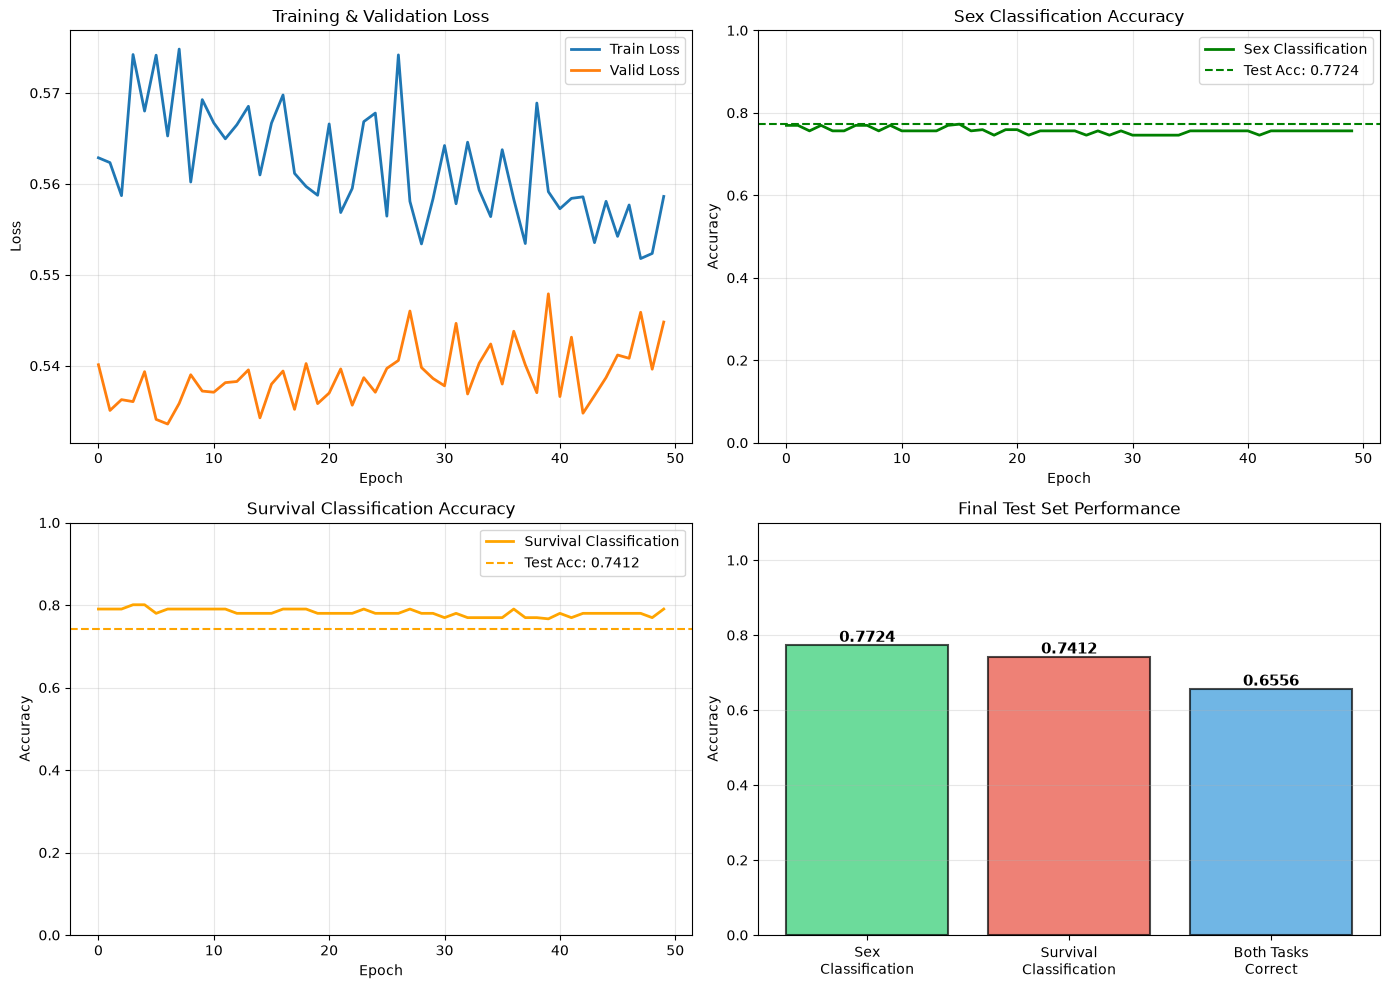


📈 학습 과정 분석

[손실 함수 개선]
  - 초기 손실: 0.562867
  - 최종 손실: 0.558618
  - 개선율: 0.75%

[각 작업별 정확도 개선 추이]
  성별 분류:
    - 초기: 0.7696
    - 최종: 0.7563
    - 최고: 0.7725 (에포크 16)
  생존 분류:
    - 초기: 0.7904
    - 최종: 0.7904
    - 최고: 0.8008 (에포크 4)

[과적합 정도 분석 (마지막 10 에포크 기준)]
  - 평균 훈련 손실: 0.556052
  - 평균 검증 손실: 0.540229
  - 과적합 정도: -2.85%
  → 우수한 일반화 성능을 보임 ✓

[예측 결과 요약]
  - 성별 작업: 70/90 정확 (77.2%)
  - 생존 작업: 67/90 정확 (74.1%)
  - 두 작업 동시 정확: 59/90 (65.6%)



In [83]:
# 테스트 세트 성능 평가
model.eval()
test_loss = 0.0
test_task_acc = np.array([0.0, 0.0])
test_all_predictions = []
test_all_true_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        outputs = model(batch_X)
        predictions = torch.sigmoid(outputs)
        
        test_loss += criterion(predictions, batch_y).item()
        pred_classes = (predictions > 0.5).float()
        test_task_acc += (pred_classes == batch_y).float().mean(dim=0).cpu().numpy()
        
        test_all_predictions.append(pred_classes.cpu().numpy())
        test_all_true_labels.append(batch_y.cpu().numpy())

test_loss /= len(test_loader)
test_task_acc /= len(test_loader)

# 전체 정확도 계산 (연결된 배열 기준)
test_all_predictions = np.vstack(test_all_predictions)
test_all_true_labels = np.vstack(test_all_true_labels)
test_exact_acc = np.mean(np.all(test_all_predictions == test_all_true_labels, axis=1))

print("\n" + "=" * 80)
print("📊 최종 성능 평가")
print("=" * 80)
print(f"\n[테스트 세트 결과]")
print(f"  - 테스트 손실: {test_loss:.4f}")
print(f"  - 성별(Sex) 분류 정확도: {test_task_acc[0]:.4f}")
print(f"  - 생존(Survived) 분류 정확도: {test_task_acc[1]:.4f}")
print(f"  - 전체 정확도 (두 작업 모두 맞은 경우): {test_exact_acc:.4f}")

print(f"\n[학습 과정 요약]")
print(f"  - 최초 훈련 손실: {history['train_loss'][0]:.4f}")
print(f"  - 최종 훈련 손실: {history['train_loss'][-1]:.4f}")
print(f"  - 최고 검증 성능 에포크: {np.argmax(history['valid_sex_acc']) + 1} (성별)")
print(f"                      {np.argmax(history['valid_survived_acc']) + 1} (생존)")

# 학습 곡선 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 손실 곡선
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['valid_loss'], label='Valid Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 성별 분류 정확도
axes[0, 1].plot(history['valid_sex_acc'], label='Sex Classification', linewidth=2, color='green')
axes[0, 1].axhline(y=test_task_acc[0], color='green', linestyle='--', label=f'Test Acc: {test_task_acc[0]:.4f}')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Sex Classification Accuracy')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 생존 분류 정확도
axes[1, 0].plot(history['valid_survived_acc'], label='Survival Classification', linewidth=2, color='orange')
axes[1, 0].axhline(y=test_task_acc[1], color='orange', linestyle='--', label=f'Test Acc: {test_task_acc[1]:.4f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Survival Classification Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 성능 비교 바 차트
tasks = ['Sex\nClassification', 'Survival\nClassification', 'Both Tasks\nCorrect']
accuracies = [test_task_acc[0], test_task_acc[1], test_exact_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[1, 1].bar(tasks, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# 바 위에 수치 표시
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Final Test Set Performance')
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📈 학습 과정 분석")
print("=" * 80)

# 손실 개선도
loss_improvement = ((history['train_loss'][0] - history['train_loss'][-1]) / history['train_loss'][0]) * 100
print(f"\n[손실 함수 개선]")
print(f"  - 초기 손실: {history['train_loss'][0]:.6f}")
print(f"  - 최종 손실: {history['train_loss'][-1]:.6f}")
print(f"  - 개선율: {loss_improvement:.2f}%")

# 정확도 분석
print(f"\n[각 작업별 정확도 개선 추이]")
print(f"  성별 분류:")
print(f"    - 초기: {history['valid_sex_acc'][0]:.4f}")
print(f"    - 최종: {history['valid_sex_acc'][-1]:.4f}")
print(f"    - 최고: {max(history['valid_sex_acc']):.4f} (에포크 {np.argmax(history['valid_sex_acc']) + 1})")

print(f"  생존 분류:")
print(f"    - 초기: {history['valid_survived_acc'][0]:.4f}")
print(f"    - 최종: {history['valid_survived_acc'][-1]:.4f}")
print(f"    - 최고: {max(history['valid_survived_acc']):.4f} (에포크 {np.argmax(history['valid_survived_acc']) + 1})")

# 과적합 분석
avg_valid_loss = np.mean(history['valid_loss'][-10:])  # 마지막 10개 에포크 평균
avg_train_loss = np.mean(history['train_loss'][-10:])
overfitting_ratio = (avg_valid_loss - avg_train_loss) / avg_train_loss * 100

print(f"\n[과적합 정도 분석 (마지막 10 에포크 기준)]")
print(f"  - 평균 훈련 손실: {avg_train_loss:.6f}")
print(f"  - 평균 검증 손실: {avg_valid_loss:.6f}")
print(f"  - 과적합 정도: {overfitting_ratio:.2f}%")
if overfitting_ratio < 5:
    print(f"  → 우수한 일반화 성능을 보임 ✓")
elif overfitting_ratio < 20:
    print(f"  → 적당한 수준의 과적합 ⚠")
else:
    print(f"  → 상당한 과적합 발생 ✗")

print(f"\n[예측 결과 요약]")
print(f"  - 성별 작업: {(test_all_predictions[:, 0] == test_all_true_labels[:, 0]).sum()}/{len(test_all_predictions)} 정확 ({test_task_acc[0]*100:.1f}%)")
print(f"  - 생존 작업: {(test_all_predictions[:, 1] == test_all_true_labels[:, 1]).sum()}/{len(test_all_predictions)} 정확 ({test_task_acc[1]*100:.1f}%)")
print(f"  - 두 작업 동시 정확: {np.sum(np.all(test_all_predictions == test_all_true_labels, axis=1))}/{len(test_all_predictions)} ({test_exact_acc*100:.1f}%)")

print("\n" + "=" * 80)